# Simple Pair Backtest

A minimal notebook to backtest any two-ETF pair with periodic rebalancing.

## What this does
- Supports long/short direction per leg
- Rebalances both legs once per chosen period
- Sizes notionals to hit a target net beta exposure (default: beta-neutral)
- Tracks equity curve, drawdown, and simple performance stats

## Starter pair
- Leg A: `APLX` (short)
- Leg B: `APLZ` (short)
- Target: net beta exposure = 0


In [ ]:
import io
import time
import ftplib
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yfple
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [ ]:
# --- Parameters ---
# Auto-select all bucket-3 inverse ETFs with negative beta from latest screener.
UNIVERSE_SOURCE_CSV = "../data/etf_screened_today.csv"

# Keep these for plotting cell compatibility; they will be set from first pair run.

START = "2024-01-01"
END = None

# Direction: +1 = long, -1 = short
# Requested setup: short inverse ETF and short underlying.
LEG_A_SIDE = -1
LEG_B_SIDE = -1

# Beta to underlying (or benchmark beta exposure) for each leg
# Used as manual fallback if auto lookup does not find a value.
# Inverse ETF leg defaults to -2x; underlying leg defaults to +1x.
LEG_A_BETA = -2.0
LEG_B_BETA = 1.0
USE_BETA_FROM_SCREENED = True
BETA_SOURCE_CSV = UNIVERSE_SOURCE_CSV

INITIAL_CAPITAL = 100_000
TARGET_GROSS_MULTIPLIER = 1.0   # gross notional as multiple of equity
TARGET_NET_BETA_NOTIONAL = 0.0  # 0 = beta-neutral

# Borrow settings (applies daily carry on short legs)
USE_BORROW_FROM_SCREENED = True
# ETF borrow: average fee-only borrow across all historical screener snapshots.
BORROW_SOURCE_GLOBS = [
    "../data/etf_screened_today.csv",
    "../data/runs/*/etf_screened_today.csv",
    "../../etf-dashboard/data/etf_screened_today.csv",
    "../../etf-dashboard/data/runs/*/etf_screened_today.csv",
]
# Underlying borrow: IBKR FTP snapshot (same method used in daily_screener.py).
USE_IBKR_FTP_FOR_UNDERLYINGS = True
FTP_HOST = "ftp2.interactivebrokers.com"
FTP_USER = "shortstock"
FTP_PASS = ""
FTP_FILE = "usa.txt"
FTP_MAX_RETRIES = 3
IBKR_BORROW_CACHE_PATH = Path("../data/borrow_cache.csv")

BORROW_FALLBACK_ANNUAL = 0.1
MANUAL_BORROW_OVERRIDE = {
    # "APLZ": 0.12,
    # "AMZN": 0.01,
}

# Bucket 4 internalization assumption: no external underlying borrow cost.
UNDERLYING_INTERNALIZED_BORROW_ANNUAL = 0.0

# Bucket 4 internalization assumption: no short-sale proceeds credit.
SHORT_PROCEEDS_ANNUAL = 0.0

# Rebalance cadence comparison set.
REBALANCE_FREQ_MAP = {
    "bi_weekly": "2W-FRI",
}
# Default used by the existing plot cell after the comparison run.
REBALANCE_FREQ = "bi-weekly"

# Per-trade cost in bps applied to gross notional traded
FEE_BPS = 0.0

In [ ]:
def _extract_close_series(raw: pd.DataFrame, ticker: str) -> pd.Series:
    """Return a 1D Close series across yfinance output shapes."""
    if raw is None or len(raw) == 0:
        return pd.Series(dtype=float, name=ticker)

    close = None
    if isinstance(raw.columns, pd.MultiIndex):
        # Common patterns:
        # - level0 has OHLC fields and level1 has ticker
        # - level0 has ticker and level1 has OHLC fields
        lvl0 = [str(x).lower() for x in raw.columns.get_level_values(0)]
        lvl1 = [str(x).lower() for x in raw.columns.get_level_values(1)]

        if "close" in lvl0:
            close = raw.xs("Close", axis=1, level=0)
        elif "close" in lvl1:
            close = raw.xs("Close", axis=1, level=1)
    else:
        if "Close" in raw.columns:
            close = raw["Close"]

    if close is None:
        raise RuntimeError(f"Missing Close column for {ticker}")

    # Ensure 1D output even if close came back as a 2D frame.
    if isinstance(close, pd.DataFrame):
        if close.shape[1] == 0:
            raise RuntimeError(f"Empty Close data for {ticker}")
        if ticker in close.columns:
            s = close[ticker]
        elif str(ticker).upper() in [str(c).upper() for c in close.columns]:
            pick = next(c for c in close.columns if str(c).upper() == str(ticker).upper())
            s = close[pick]
        else:
            s = close.iloc[:, 0]
    else:
        s = close

    return pd.to_numeric(s, errors="coerce").rename(ticker)


def load_prices(leg_a_ticker: str, leg_b_ticker: str, start: str, end: str | None = None) -> pd.DataFrame:
    # Pull each leg independently so we can explicitly align to the later
    # first-valid date (true common-live window for decay calculations).
    a_raw = yf.download(
        leg_a_ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
    )
    b_raw = yf.download(
        leg_b_ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
    )

    a = _extract_close_series(a_raw, leg_a_ticker).rename("a_px")
    b = _extract_close_series(b_raw, leg_b_ticker).rename("b_px")

    first_a = a.dropna().index.min()
    first_b = b.dropna().index.min()
    if pd.isna(first_a) or pd.isna(first_b):
        raise RuntimeError(f"No valid price history for selected pair: {leg_a_ticker}/{leg_b_ticker}")

    aligned_start = max(first_a, first_b)
    if aligned_start > pd.Timestamp(start):
        print(
            f"[PAIR START] {leg_a_ticker}/{leg_b_ticker} aligned start moved "
            f"from {pd.Timestamp(start).date()} to {aligned_start.date()}"
        )

    px = pd.concat([a, b], axis=1)
    px = px.loc[px.index >= aligned_start].dropna()
    if px.empty:
        raise RuntimeError("No overlapping price data for selected pair after start alignment.")
    return px


def _norm_sym(x: str) -> str:
    return str(x).strip().upper()


def _pick_borrow_fee_only(row: pd.Series) -> float | None:
    # Match dashboard behavior: prefer fee-only borrow fields.
    for key in ("borrow_current", "borrow_fee_annual", "borrow_net_annual"):
        if key not in row.index:
            continue
        v = row.get(key)
        if pd.isna(v):
            continue
        try:
            return float(v)
        except Exception:
            continue
    return None


def _collect_screened_csv_paths(glob_patterns: list[str] | str) -> list[str]:
    patterns = [glob_patterns] if isinstance(glob_patterns, str) else list(glob_patterns)
    out: list[str] = []
    seen: set[str] = set()

    for pattern in patterns:
        if not pattern:
            continue
        for p in Path().glob(pattern):
            if not p.is_file():
                continue
            rp = str(p.resolve())
            if rp in seen:
                continue
            seen.add(rp)
            out.append(rp)

    out.sort()
    return out


def load_bucket3_pairs(screened_csv: str) -> list[tuple[str, str]]:
    df = pd.read_csv(screened_csv)
    cols = {c.lower(): c for c in df.columns}
    etf_col = cols.get("etf")
    und_col = cols.get("underlying")
    bucket_col = cols.get("bucket")
    beta_col = cols.get("beta")

    required = {"etf": etf_col, "underlying": und_col, "beta": beta_col}
    missing = [k for k, v in required.items() if v is None]
    if missing:
        raise ValueError(f"Missing required columns in {screened_csv}: {missing}")

    if bucket_col:
        tmp = df[[etf_col, und_col, bucket_col, beta_col]].copy()
    else:
        # Some snapshots only include screened rows with no explicit bucket column.
        tmp = df[[etf_col, und_col, beta_col]].copy()

    tmp[etf_col] = tmp[etf_col].astype(str).map(_norm_sym)
    tmp[und_col] = tmp[und_col].astype(str).map(_norm_sym)
    tmp[beta_col] = pd.to_numeric(tmp[beta_col], errors="coerce")

    m = tmp[beta_col].notna() & (tmp[beta_col] < 0) & tmp[etf_col].ne("") & tmp[und_col].ne("")
    if bucket_col:
        m = m & tmp[bucket_col].astype(str).str.lower().eq("bucket_3_inverse")

    sel = tmp.loc[m, [etf_col, und_col]].drop_duplicates()
    pairs = [(r[etf_col], r[und_col]) for _, r in sel.iterrows()]
    if not pairs:
        raise RuntimeError("No inverse negative-beta pairs found in screener.")
    return pairs


def _parse_ftp_text(text: str) -> pd.DataFrame:
    lines = [ln for ln in text.splitlines() if ln.strip()]
    header_idx = next((i for i, ln in enumerate(lines) if ln.startswith("#SYM|")), None)
    if header_idx is None:
        raise ValueError("Could not find header line '#SYM|'")
    header_cols = [c.strip().lstrip("#").lower() for c in lines[header_idx].split("|")]
    data_lines = lines[header_idx + 1 :]
    df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep="|", header=None, engine="python")
    df = df.iloc[:, : min(len(header_cols), df.shape[1])]
    df.columns = header_cols[: df.shape[1]]
    return df.drop(columns=[c for c in df.columns if not c or str(c).startswith("unnamed")], errors="ignore")


def fetch_ibkr_shortstock_file(
    filename: str = FTP_FILE,
    max_retries: int = FTP_MAX_RETRIES,
    cache_path: Path = IBKR_BORROW_CACHE_PATH,
) -> pd.DataFrame:
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            print(f"[FTP] Connecting to {FTP_HOST} ... (attempt {attempt}/{max_retries})")
            ftp = ftplib.FTP(timeout=30)
            try:
                ftp.connect(FTP_HOST, 21)
                ftp.login(user=FTP_USER, passwd=FTP_PASS)
                ftp.set_pasv(True)
                buf = io.BytesIO()
                ftp.retrbinary(f"RETR {filename}", buf.write)
            finally:
                try:
                    ftp.quit()
                except Exception:
                    try:
                        ftp.close()
                    except Exception:
                        pass

            text = buf.getvalue().decode("utf-8", errors="ignore")
            df = _parse_ftp_text(text)
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            df.to_csv(cache_path, index=False)
            print(f"[FTP] Parsed {len(df)} rows (cached to {cache_path})")
            return df
        except Exception as e:
            last_err = e
            if attempt < max_retries:
                time.sleep(2 ** attempt)

    if cache_path.exists():
        print(f"[FTP] All retries failed. Falling back to cache: {cache_path}")
        return pd.read_csv(cache_path)
    raise ConnectionError(f"IBKR FTP unavailable and no cache present. Last error: {last_err}")


def _parse_rate_to_decimal(x) -> float:
    if x is None:
        return np.nan
    s = str(x).strip()
    if s == "" or s.upper() in {"N/A", "NA", "NONE", "NULL"}:
        return np.nan
    s = s.replace("%", "").strip()
    try:
        return float(s) / 100.0
    except Exception:
        return np.nan


def get_ibkr_borrow_map(symbols: list[str]) -> dict[str, float]:
    symbols = list(dict.fromkeys([_norm_sym(s) for s in symbols if str(s).strip()]))
    if not symbols:
        return {}

    short_df = fetch_ibkr_shortstock_file(FTP_FILE)
    for req in ("sym", "feerate"):
        if req not in short_df.columns:
            raise ValueError(f"Expected '{req}' column; got: {list(short_df.columns)}")

    df = short_df.copy()
    df["sym"] = df["sym"].astype(str).str.upper().str.strip()
    df["borrow_fee_annual"] = df["feerate"].map(_parse_rate_to_decimal)

    agg = (
        df.groupby("sym", as_index=False)
        .agg(borrow_fee_annual=("borrow_fee_annual", "max"))
        .dropna(subset=["borrow_fee_annual"])
    )
    return {str(r["sym"]): float(r["borrow_fee_annual"]) for _, r in agg.iterrows() if str(r["sym"]) in symbols}


def load_pair_borrow_rates(
    ticker_a: str,
    ticker_b: str,
    screened_csv_globs: list[str] | str,
    use_screened: bool,
    fallback_annual: float,
    underlying_ibkr_map: dict[str, float] | None = None,
    manual_override: dict[str, float] | None = None,
) -> tuple[float, float]:
    ticker_a = _norm_sym(ticker_a)
    ticker_b = _norm_sym(ticker_b)
    rates = {ticker_a: float(fallback_annual), ticker_b: float(fallback_annual)}

    # ETF leg: use historical average from screener snapshots.
    if use_screened:
        vals_a: list[float] = []
        for path in _collect_screened_csv_paths(screened_csv_globs):
            try:
                df = pd.read_csv(path)
            except Exception:
                continue
            if "ETF" not in df.columns:
                continue
            df["ETF"] = df["ETF"].astype(str).str.upper().str.strip()
            for _, row in df.iterrows():
                if str(row.get("ETF", "")).upper().strip() != ticker_a:
                    continue
                borrow = _pick_borrow_fee_only(row)
                if borrow is not None and np.isfinite(borrow):
                    vals_a.append(float(borrow))
        if vals_a:
            rates[ticker_a] = float(np.mean(vals_a))

    # Underlying leg: use IBKR FTP map (daily_screener method).
    if underlying_ibkr_map is not None and ticker_b in underlying_ibkr_map and np.isfinite(underlying_ibkr_map[ticker_b]):
        rates[ticker_b] = float(underlying_ibkr_map[ticker_b])

    if manual_override:
        for k, v in manual_override.items():
            rates[_norm_sym(k)] = float(v)

    return rates[ticker_a], rates[ticker_b]


def load_beta_values(
    ticker_a: str,
    ticker_b: str,
    screened_csv: str,
    use_screened: bool,
    fallback_a: float,
    fallback_b: float,
) -> tuple[float, float]:
    beta_map = {_norm_sym(ticker_a): float(fallback_a), _norm_sym(ticker_b): float(fallback_b)}

    if use_screened:
        try:
            df = pd.read_csv(screened_csv)
            cols_lower = {c.lower(): c for c in df.columns}
            etf_col = cols_lower.get("etf")
            beta_col = cols_lower.get("beta")
            if etf_col and beta_col:
                df[etf_col] = df[etf_col].astype(str).str.upper().str.strip()
                tmp = df[[etf_col, beta_col]].dropna()
                for _, r in tmp.iterrows():
                    etf = str(r[etf_col])
                    if etf in beta_map:
                        beta_map[etf] = float(r[beta_col])
        except Exception as e:
            print(f"[WARN] Could not load betas from {screened_csv}: {e}")

    return beta_map[_norm_sym(ticker_a)], beta_map[_norm_sym(ticker_b)]


def solve_beta_hedged_notionals(
    gross_notional: float,
    side_a: float,
    side_b: float,
    beta_a: float,
    beta_b: float,
    target_net_beta_notional: float = 0.0,
) -> tuple[float, float]:
    a = float(side_a) * float(beta_a)
    b = float(side_b) * float(beta_b)
    g = float(gross_notional)
    t = float(target_net_beta_notional)

    denom = a - b
    if abs(denom) < 1e-12:
        n_a = 0.5 * g
        n_b = 0.5 * g
    else:
        n_a = (t - b * g) / denom
        n_b = g - n_a

    n_a = max(0.0, n_a)
    n_b = max(0.0, n_b)
    s = n_a + n_b
    if s <= 0:
        return 0.5 * g, 0.5 * g
    return g * n_a / s, g * n_b / s


def run_pair_backtest(
    prices: pd.DataFrame,
    rebal_freq: str = "W-FRI",
    initial_capital: float = 100_000,
    gross_multiplier: float = 1.0,
    side_a: float = -1.0,
    side_b: float = -1.0,
    beta_a: float = 2.0,
    beta_b: float = -2.0,
    target_net_beta_notional: float = 0.0,
    borrow_a_annual: float = 0.0,
    borrow_b_annual: float = 0.0,
    short_proceeds_annual: float = 0.0,
    fee_bps: float = 0.0,
) -> pd.DataFrame:
    bt = prices.copy()
    bt["rebalance"] = False

    rf = str(rebal_freq).upper().strip()
    if rf == "TWICE_WEEKLY":
        rebalance_dates = bt.resample("W-TUE").last().index.union(bt.resample("W-FRI").last().index)
    elif rf in REBALANCE_FREQ_MAP and REBALANCE_FREQ_MAP[rf].upper() != "TWICE_WEEKLY":
        rebalance_dates = bt.resample(REBALANCE_FREQ_MAP[rf]).last().index
    else:
        rebalance_dates = bt.resample(rebal_freq).last().index

    bt.loc[bt.index.isin(rebalance_dates), "rebalance"] = True
    bt.iloc[0, bt.columns.get_loc("rebalance")] = True

    a_sh = 0.0
    b_sh = 0.0
    cash = float(initial_capital)

    rows = []
    fee_rate = fee_bps / 10_000.0
    borrow_a_daily = float(borrow_a_annual) / 252.0
    borrow_b_daily = float(borrow_b_annual) / 252.0
    short_proceeds_daily = float(short_proceeds_annual) / 252.0

    for dt, row in bt.iterrows():
        ap = float(row["a_px"])
        bp = float(row["b_px"])

        a_pos_notional = a_sh * ap
        b_pos_notional = b_sh * bp

        borrow_cost = 0.0
        short_proceeds_credit = 0.0
        if a_pos_notional < 0:
            borrow_cost += abs(a_pos_notional) * borrow_a_daily
            short_proceeds_credit += abs(a_pos_notional) * short_proceeds_daily
        if b_pos_notional < 0:
            borrow_cost += abs(b_pos_notional) * borrow_b_daily
            short_proceeds_credit += abs(b_pos_notional) * short_proceeds_daily

        financing_pnl = short_proceeds_credit - borrow_cost
        cash += financing_pnl

        equity = cash + a_pos_notional + b_pos_notional

        if bool(row["rebalance"]):
            target_gross = max(0.0, float(gross_multiplier) * equity)
            n_a, n_b = solve_beta_hedged_notionals(
                gross_notional=target_gross,
                side_a=side_a,
                side_b=side_b,
                beta_a=beta_a,
                beta_b=beta_b,
                target_net_beta_notional=target_net_beta_notional,
            )

            target_a_pos = float(side_a) * n_a
            target_b_pos = float(side_b) * n_b

            delta_a = target_a_pos - a_pos_notional
            delta_b = target_b_pos - b_pos_notional

            traded_gross = abs(delta_a) + abs(delta_b)
            fee = traded_gross * fee_rate

            cash -= delta_a
            cash -= delta_b
            cash -= fee

            a_sh = target_a_pos / ap if ap > 0 else 0.0
            b_sh = target_b_pos / bp if bp > 0 else 0.0

            a_pos_notional = a_sh * ap
            b_pos_notional = b_sh * bp
            equity = cash + a_pos_notional + b_pos_notional

        beta_notional = side_a * beta_a * abs(a_pos_notional) + side_b * beta_b * abs(b_pos_notional)

        rows.append(
            {
                "date": dt,
                "a_px": ap,
                "b_px": bp,
                "cash": cash,
                "a_shares": a_sh,
                "b_shares": b_sh,
                "a_pos_notional": a_pos_notional,
                "b_pos_notional": b_pos_notional,
                "gross_notional": abs(a_pos_notional) + abs(b_pos_notional),
                "beta_notional": beta_notional,
                "borrow_cost": borrow_cost,
                "short_proceeds_credit": short_proceeds_credit,
                "financing_pnl": financing_pnl,
                "equity": equity,
                "rebalance": bool(row["rebalance"]),
            }
        )

    out = pd.DataFrame(rows).set_index("date")
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["cum_return"] = out["equity"] / out["equity"].iloc[0] - 1.0
    out["drawdown"] = out["equity"].div(out["equity"].cummax()).sub(1.0)
    out["cum_borrow_cost"] = out["borrow_cost"].cumsum()
    out["cum_short_proceeds_credit"] = out["short_proceeds_credit"].cumsum()
    out["cum_financing_pnl"] = out["financing_pnl"].cumsum()
    return out


def perf_stats(bt: pd.DataFrame) -> pd.Series:
    n = len(bt)
    if n < 2:
        return pd.Series(dtype=float)

    total_return = bt["equity"].iloc[-1] / bt["equity"].iloc[0] - 1.0
    ann_factor = 252 / max(1, n - 1)
    cagr = (1 + total_return) ** ann_factor - 1 if total_return > -1 else np.nan

    vol = bt["ret"].std() * np.sqrt(252)
    sharpe = (bt["ret"].mean() * 252 / vol) if vol > 0 else np.nan
    max_dd = bt["drawdown"].min()

    return pd.Series(
        {
            "Total Return": total_return,
            "CAGR": cagr,
            "Annual Vol": vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Avg |Beta Notional|": bt["beta_notional"].abs().mean(),
            "Total Borrow Cost": bt["borrow_cost"].sum(),
            "Total Short Proceeds Credit": bt.get("short_proceeds_credit", pd.Series(dtype=float)).sum(),
            "Net Financing PnL": bt.get("financing_pnl", pd.Series(dtype=float)).sum(),
            "Rebalance Count": int(bt["rebalance"].sum()),
        }
    )

In [ ]:
BUCKET3_PAIRS = load_bucket3_pairs(UNIVERSE_SOURCE_CSV)
print(f"Loaded {len(BUCKET3_PAIRS)} inverse negative-beta pairs from {UNIVERSE_SOURCE_CSV}")

# Pull all underlying borrow rates in one FTP snapshot (daily_screener method).
underlying_symbols = sorted({und for _, und in BUCKET3_PAIRS})
underlying_ibkr_map: dict[str, float] = {}
print("[INFO] Using internalized underlying borrow = 0.0% annual")

pair_results: dict[tuple[str, str, str], dict] = {}
summary_rows: list[dict] = []
side_map = {1: "LONG", -1: "SHORT"}

for freq_label, freq_value in REBALANCE_FREQ_MAP.items():
    print(f"\n=== Rebalance mode: {freq_label} ({freq_value}) ===")
    for etf_sym, und_sym in BUCKET3_PAIRS:
        prices_i = load_prices(etf_sym, und_sym, START, END)

        beta_a_i, beta_b_i = load_beta_values(
            etf_sym,
            und_sym,
            BETA_SOURCE_CSV,
            USE_BETA_FROM_SCREENED,
            LEG_A_BETA,
            LEG_B_BETA,
        )

        borrow_a_i, _borrow_b_i = load_pair_borrow_rates(
            etf_sym,
            und_sym,
            BORROW_SOURCE_GLOBS,
            USE_BORROW_FROM_SCREENED,
            BORROW_FALLBACK_ANNUAL,
            underlying_ibkr_map=underlying_ibkr_map,
            manual_override=MANUAL_BORROW_OVERRIDE,
        )
        borrow_b_i = float(UNDERLYING_INTERNALIZED_BORROW_ANNUAL)

        bt_i = run_pair_backtest(
            prices_i,
            rebal_freq=freq_value,
            initial_capital=INITIAL_CAPITAL,
            gross_multiplier=TARGET_GROSS_MULTIPLIER,
            side_a=LEG_A_SIDE,
            side_b=LEG_B_SIDE,
            beta_a=beta_a_i,
            beta_b=beta_b_i,
            target_net_beta_notional=TARGET_NET_BETA_NOTIONAL,
            borrow_a_annual=borrow_a_i,
            borrow_b_annual=borrow_b_i,
            short_proceeds_annual=SHORT_PROCEEDS_ANNUAL,
            fee_bps=FEE_BPS,
        )

        stats_i = perf_stats(bt_i)
        pair_results[(freq_label, etf_sym, und_sym)] = {
            "prices": prices_i,
            "bt": bt_i,
            "stats": stats_i,
            "beta_a": beta_a_i,
            "beta_b": beta_b_i,
            "borrow_a": borrow_a_i,
            "borrow_b": borrow_b_i,
        }

        summary_rows.append(
            {
                "rebalance": freq_label,
                "pair": f"{etf_sym}/{und_sym}",
                "total_return": stats_i.get("Total Return", np.nan),
                "cagr": stats_i.get("CAGR", np.nan),
                "max_drawdown": stats_i.get("Max Drawdown", np.nan),
                "sharpe": stats_i.get("Sharpe", np.nan),
                "avg_abs_beta_notional": stats_i.get("Avg |Beta Notional|", np.nan),
                "total_borrow_cost": stats_i.get("Total Borrow Cost", np.nan),
                "total_short_proceeds_credit": stats_i.get("Total Short Proceeds Credit", np.nan),
                "net_financing_pnl": stats_i.get("Net Financing PnL", np.nan),
                "borrow_etf_hist_avg": borrow_a_i,
                "borrow_underlying_ibkr": borrow_b_i,
                "short_proceeds_rate": SHORT_PROCEEDS_ANNUAL,
            }
        )

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["rebalance", "total_return"], ascending=[True, False]).reset_index(drop=True)
display(summary_df)

# Aggregate comparison by rebalance cadence.
freq_compare = (
    summary_df.groupby("rebalance", as_index=False)
    .agg(
        pairs=("pair", "count"),
        avg_total_return=("total_return", "mean"),
        median_total_return=("total_return", "median"),
        avg_cagr=("cagr", "mean"),
        avg_sharpe=("sharpe", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        avg_net_financing_pnl=("net_financing_pnl", "mean"),
    )
    .sort_values("avg_total_return", ascending=False)
    .reset_index(drop=True)
)
display(freq_compare)

Loaded 44 inverse negative-beta pairs from ../data/etf_screened_today.csv
[FTP] Connecting to ftp2.interactivebrokers.com ... (attempt 1/3)
[FTP] Parsed 18941 rows (cached to ..\data\borrow_cache.csv)
IBKR borrow loaded for 29/29 underlyings

=== Rebalance mode: bi_weekly (2W-FRI) ===
[PAIR START] SDS/SPY aligned start moved from 2024-01-01 to 2024-01-02
[PAIR START] QID/QQQ aligned start moved from 2024-01-01 to 2024-01-02
[PAIR START] DXD/DIA aligned start moved from 2024-01-01 to 2024-01-02
[PAIR START] TWM/IWM aligned start moved from 2024-01-01 to 2024-01-02
[PAIR START] SCO/USO aligned start moved from 2024-01-01 to 2024-01-02
[PAIR START] MSTZ/MSTR aligned start moved from 2024-01-01 to 2024-09-18
[PAIR START] NVDQ/NVDA aligned start moved from 2024-01-01 to 2024-01-02
[PAIR START] BTCZ/IBIT aligned start moved from 2024-01-01 to 2024-07-10
[PAIR START] ETHD/ETHA aligned start moved from 2024-01-01 to 2024-07-23
[PAIR START] CRCD/CRCL aligned start moved from 2024-01-01 to 2025-

,rebalance,pair,total_return,cagr,max_drawdown,sharpe,avg_abs_beta_notional,total_borrow_cost,total_short_proceeds_credit,net_financing_pnl,borrow_etf_hist_avg,borrow_underlying_ibkr,short_proceeds_rate
0,bi_weekly,APLZ/APLD,0.260458,1.945318,-0.024839,3.568363,12949.891529,2661.828685,872.278086,-1789.550598,0.339556,0.004234,0.037
1,bi_weekly,MSTZ/MSTR,0.211921,0.132237,-0.283709,0.536372,15082.167162,31731.310831,6077.732286,-25653.578546,0.581919,0.002963,0.037
2,bi_weekly,TSLQ/TSLA,0.188594,0.079521,-0.190306,0.636766,9143.086572,4527.752339,9023.452021,4495.699682,0.049032,0.002500,0.037
3,bi_weekly,IREZ/IREN,0.124773,0.731020,-0.048533,2.888743,17416.469773,5779.220863,833.674439,-4945.546424,0.774380,0.003791,0.037
4,bi_weekly,NVDQ/NVDA,0.109121,0.046937,-0.047987,0.689569,8681.666335,16775.400392,8785.589540,-7989.810851,0.210582,0.003648,0.037
5,bi_weekly,CLSZ/CLSK,0.085461,0.804772,-0.005180,7.038487,11591.322623,437.113255,523.514092,86.400837,0.092025,0.004134,0.037
6,bi_weekly,SOXS/SOXX,0.083310,0.036075,-0.051974,0.429299,9584.412302,11149.973950,8794.605312,-2355.368638,0.150294,0.013843,0.037
7,bi_weekly,FNGD/XLK,0.072927,0.031666,-0.151689,0.393984,7402.954311,14222.462438,9371.193060,-4851.269378,0.208267,0.004149,0.037
8,bi_weekly,NBIZ/NBIS,0.063765,0.334381,-0.100321,0.926815,21221.465233,2447.701390,843.863074,-1603.838316,0.340392,0.006509,0.037
9,bi_weekly,BEZ/BE,0.048990,0.351635,-0.047772,1.795824,13414.458027,3510.644229,598.088414,-2912.555815,0.703089,0.002500,0.037


,rebalance,pairs,avg_total_return,median_total_return,avg_cagr,avg_sharpe,avg_max_drawdown,avg_net_financing_pnl
0,bi_weekly,44,-0.056876,-0.060211,0.036964,-1.177959,-0.128424,-5778.160524


[INFO] REBALANCE_FREQ not found in summary_df; using 'bi_weekly'


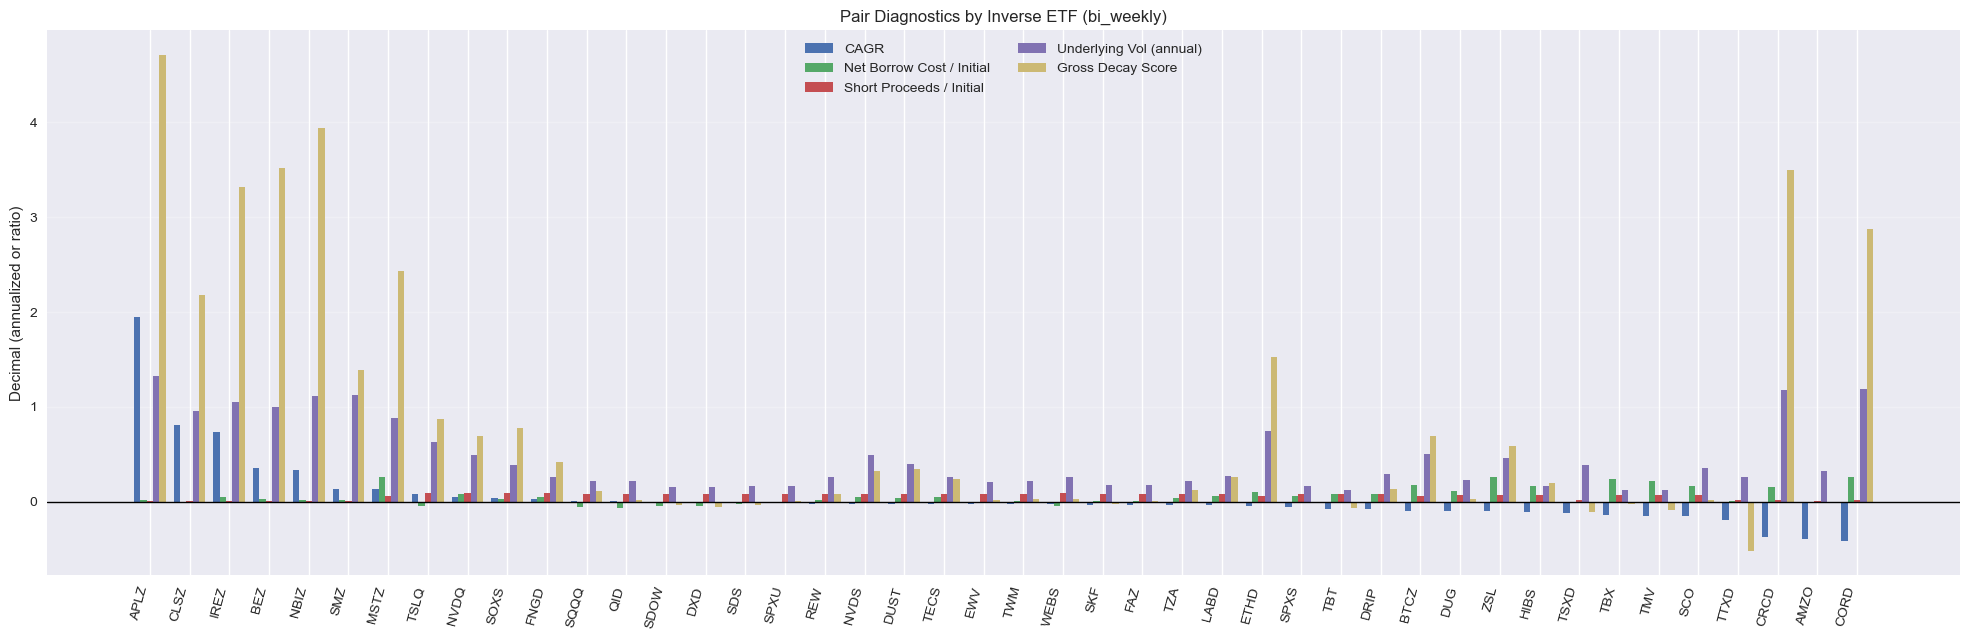

,rebalance,pair,cagr,net_borrow_cost,total_short_proceeds_credit,underlying_vol,gross_decay
0,bi_weekly,APLZ/APLD,1.945318,1789.550598,872.278086,1.324579,4.710088
1,bi_weekly,CLSZ/CLSK,0.804772,-86.400837,523.514092,0.953073,2.179847
2,bi_weekly,IREZ/IREN,0.731020,4945.546424,833.674439,1.052432,3.321808
3,bi_weekly,BEZ/BE,0.351635,2912.555815,598.088414,0.998376,3.515301
4,bi_weekly,NBIZ/NBIS,0.334381,1603.838316,843.863074,1.112607,3.939806
5,bi_weekly,SMZ/SMR,0.132338,2009.240320,586.517846,1.124313,1.393471
6,bi_weekly,MSTZ/MSTR,0.132237,25653.578546,6077.732286,0.878670,2.432059
7,bi_weekly,TSLQ/TSLA,0.079521,-4495.699682,9023.452021,0.625691,0.872715
8,bi_weekly,NVDQ/NVDA,0.046937,7989.810851,8785.589540,0.493840,0.692212
9,bi_weekly,SOXS/SOXX,0.036075,2355.368638,8794.605312,0.384346,0.780176


: 

In [ ]:
# Bar chart diagnostics by inverse ETF for the selected rebalance cadence.
if "summary_df" not in globals() or summary_df.empty:
    raise RuntimeError("Run the backtest cell first to generate summary_df.")

rebalance_alias = {
    "bi-weekly": "bi_weekly",
    "bi_weekly": "bi_weekly",
    "weekly": "weekly",
    "twice-weekly": "twice_weekly",
    "twice_weekly": "twice_weekly",
    "monthly": "monthly",
}
selected_rebalance = rebalance_alias.get(str(REBALANCE_FREQ).lower(), str(REBALANCE_FREQ))
if selected_rebalance not in set(summary_df["rebalance"].astype(str)):
    selected_rebalance = str(summary_df["rebalance"].iloc[0])
    print(f"[INFO] REBALANCE_FREQ not found in summary_df; using '{selected_rebalance}'")

screened = pd.read_csv(UNIVERSE_SOURCE_CSV)
cols = {c.lower(): c for c in screened.columns}

etf_col = cols.get("etf")
und_col = cols.get("underlying")
und_vol_col = cols.get("vol_underlying_annual")
gross_decay_col = cols.get("gross_decay_annual")
if not etf_col or not und_col:
    raise RuntimeError("UNIVERSE_SOURCE_CSV must include ETF and Underlying columns")
if not und_vol_col or not gross_decay_col:
    raise RuntimeError("UNIVERSE_SOURCE_CSV must include vol_underlying_annual and gross_decay_annual")

plot_df = summary_df.copy()
plot_df = plot_df[plot_df["rebalance"].astype(str) == selected_rebalance].copy()
if plot_df.empty:
    raise RuntimeError(f"No rows for rebalance cadence '{selected_rebalance}'")

plot_df[["etf", "underlying"]] = plot_df["pair"].str.split("/", n=1, expand=True)
plot_df["etf"] = plot_df["etf"].astype(str).str.upper().str.strip()
plot_df["underlying"] = plot_df["underlying"].astype(str).str.upper().str.strip()

meta = screened[[etf_col, und_col, und_vol_col, gross_decay_col]].copy()
meta.columns = ["etf", "underlying", "underlying_vol", "gross_decay"]
meta["etf"] = meta["etf"].astype(str).str.upper().str.strip()
meta["underlying"] = meta["underlying"].astype(str).str.upper().str.strip()

plot_df = plot_df.merge(meta, on=["etf", "underlying"], how="left")
plot_df["net_borrow_cost"] = pd.to_numeric(plot_df.get("total_borrow_cost"), errors="coerce") - pd.to_numeric(plot_df.get("total_short_proceeds_credit"), errors="coerce")
plot_df["net_borrow_cost_pct"] = plot_df["net_borrow_cost"] / float(INITIAL_CAPITAL)
plot_df["short_proceeds_pct"] = pd.to_numeric(plot_df.get("total_short_proceeds_credit"), errors="coerce") / float(INITIAL_CAPITAL)
plot_df["cagr"] = pd.to_numeric(plot_df.get("cagr"), errors="coerce")
plot_df["underlying_vol"] = pd.to_numeric(plot_df.get("underlying_vol"), errors="coerce")
plot_df["gross_decay"] = pd.to_numeric(plot_df.get("gross_decay"), errors="coerce")

plot_df = plot_df.sort_values("cagr", ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.16
fig, ax = plt.subplots(figsize=(max(12, len(plot_df) * 0.45), 6.5))

ax.bar(x - 2 * width, plot_df["cagr"], width, label="CAGR")
ax.bar(x - width, plot_df["net_borrow_cost_pct"], width, label="Net Borrow Cost / Initial")
ax.bar(x, plot_df["short_proceeds_pct"], width, label="Short Proceeds / Initial")
ax.bar(x + width, plot_df["underlying_vol"], width, label="Underlying Vol (annual)")
ax.bar(x + 2 * width, plot_df["gross_decay"], width, label="Gross Decay Score")

ax.set_title(f"Pair Diagnostics by Inverse ETF ({selected_rebalance})")
ax.set_ylabel("Decimal (annualized or ratio)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["etf"], rotation=75, ha="right")
ax.axhline(0.0, color="black", linewidth=1)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

display(
    plot_df[
        [
            "rebalance",
            "pair",
            "cagr",
            "net_borrow_cost",
            "total_short_proceeds_credit",
            "underlying_vol",
            "gross_decay",
        ]
    ]
)

## Bucket 4 Hedge-Ratio Test

This test sweeps the Bucket 4 underlying hedge fraction and reports:

- historical average CAGR and max drawdown across Bucket 4 candidate pairs
- drift-adjusted expected CAGR/Calmar for 6%, 8%, and 10% underlying drift assumptions

Interpretation:

- lower hedge fraction (`<1.0`) keeps more long-beta residual
- higher hedge fraction (`>1.0`) over-hedges and can become short-beta

In [ ]:
# --- Bucket 4 hedge-fraction sweep ---
HEDGE_FRACTIONS = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
DRIFT_SCENARIOS = {"mu_6pct": 0.06, "mu_8pct": 0.08, "mu_10pct": 0.10}
BUCKET4_REBAL_FREQ = REBALANCE_FREQ_MAP.get("bi_weekly", "2W-FRI")
MIN_UNDERLYING_VOL = 0.60
MIN_NET_DECAY = 0.20


def load_bucket4_pairs(screened_csv: str) -> list[tuple[str, str]]:
    df = pd.read_csv(screened_csv)
    cols = {c.lower(): c for c in df.columns}
    etf_col = cols.get("etf")
    und_col = cols.get("underlying")
    beta_col = cols.get("beta")
    bucket_col = cols.get("bucket")

    if etf_col is None or und_col is None or beta_col is None:
        raise ValueError("screened_csv must include ETF/Underlying/Beta columns")

    vol_candidates = [
        "vol_underlying_annual",
        "underlying_vol_annual",
        "underlying_vol",
        "underlying_volatility_annual",
        "underlying_realized_vol_annual",
    ]
    decay_candidates = [
        "bucket4_net_edge_annual",
        "net_decay_annual",
        "net_edge_annual",
    ]

    vol_col = next((cols[c] for c in vol_candidates if c in cols), None)
    decay_col = next((cols[c] for c in decay_candidates if c in cols), None)
    if vol_col is None:
        raise ValueError(f"Could not find an underlying vol column. Tried: {vol_candidates}")
    if decay_col is None:
        raise ValueError(f"Could not find a net decay column. Tried: {decay_candidates}")

    use_cols = [etf_col, und_col, beta_col, vol_col, decay_col] + ([bucket_col] if bucket_col else [])
    tmp = df[use_cols].copy()
    tmp[etf_col] = tmp[etf_col].astype(str).map(_norm_sym)
    tmp[und_col] = tmp[und_col].astype(str).map(_norm_sym)
    tmp[beta_col] = pd.to_numeric(tmp[beta_col], errors="coerce")
    tmp[vol_col] = pd.to_numeric(tmp[vol_col], errors="coerce")
    tmp[decay_col] = pd.to_numeric(tmp[decay_col], errors="coerce")

    mask = tmp[beta_col].notna() & (tmp[beta_col] < 0) & tmp[etf_col].ne("") & tmp[und_col].ne("")
    if bucket_col:
        b = tmp[bucket_col].astype(str).str.lower()
        mask = mask & b.isin(["bucket_4", "bucket_3_inverse", "bucket_3"])

    # Requested filters: underlying vol > 60% and net decay > 20%.
    mask = mask & (tmp[vol_col] > MIN_UNDERLYING_VOL) & (tmp[decay_col] > MIN_NET_DECAY)

    out = tmp.loc[mask, [etf_col, und_col]].drop_duplicates()
    pairs = [(r[etf_col], r[und_col]) for _, r in out.iterrows()]
    print(
        f"[FILTER] bucket4 pairs with {vol_col} > {MIN_UNDERLYING_VOL:.0%} and "
        f"{decay_col} > {MIN_NET_DECAY:.0%}: {len(pairs)}"
    )
    if not pairs:
        raise RuntimeError("No bucket-4 candidate pairs found after vol/decay filters")
    return pairs


def run_bucket4_pair_backtest_hedge_fraction(
    prices: pd.DataFrame,
    hedge_fraction: float,
    rebal_freq: str = "2W-FRI",
    initial_capital: float = 100_000,
    gross_multiplier: float = 1.0,
    beta_a: float = -2.0,
    beta_b: float = 1.0,
    borrow_a_annual: float = 0.0,
    borrow_b_annual: float = 0.0,
    short_proceeds_annual: float = 0.0,
    fee_bps: float = 0.0,
) -> pd.DataFrame:
    bt = prices.copy()
    bt["rebalance"] = False

    rf = str(rebal_freq).upper().strip()
    if rf == "TWICE_WEEKLY":
        rebalance_dates = bt.resample("W-TUE").last().index.union(bt.resample("W-FRI").last().index)
    else:
        rebalance_dates = bt.resample(rebal_freq).last().index

    bt.loc[bt.index.isin(rebalance_dates), "rebalance"] = True
    bt.iloc[0, bt.columns.get_loc("rebalance")] = True

    a_sh, b_sh = 0.0, 0.0
    cash = float(initial_capital)
    fee_rate = fee_bps / 10_000.0
    borrow_a_daily = float(borrow_a_annual) / 252.0
    borrow_b_daily = float(borrow_b_annual) / 252.0
    short_proceeds_daily = float(short_proceeds_annual) / 252.0

    beta_inv_abs = abs(float(beta_a))
    h = float(hedge_fraction)

    rows = []
    for dt, row in bt.iterrows():
        ap = float(row["a_px"])
        bp = float(row["b_px"])

        a_pos_notional = a_sh * ap
        b_pos_notional = b_sh * bp

        borrow_cost = 0.0
        short_proceeds_credit = 0.0
        if a_pos_notional < 0:
            borrow_cost += abs(a_pos_notional) * borrow_a_daily
            short_proceeds_credit += abs(a_pos_notional) * short_proceeds_daily
        if b_pos_notional < 0:
            borrow_cost += abs(b_pos_notional) * borrow_b_daily
            short_proceeds_credit += abs(b_pos_notional) * short_proceeds_daily

        financing_pnl = short_proceeds_credit - borrow_cost
        cash += financing_pnl
        equity = cash + a_pos_notional + b_pos_notional

        if bool(row["rebalance"]):
            target_gross = max(0.0, float(gross_multiplier) * equity)
            # bucket4 construction: short inverse ETF + short underlying
            # full beta hedge when h=1.0, under-hedged when h<1.0
            denom = 1.0 + h * beta_inv_abs
            n_a = target_gross / denom if denom > 1e-12 else 0.5 * target_gross
            n_b = max(0.0, target_gross - n_a)

            target_a_pos = -n_a
            target_b_pos = -n_b

            delta_a = target_a_pos - a_pos_notional
            delta_b = target_b_pos - b_pos_notional
            traded_gross = abs(delta_a) + abs(delta_b)
            fee = traded_gross * fee_rate

            cash -= delta_a
            cash -= delta_b
            cash -= fee

            a_sh = target_a_pos / ap if ap > 0 else 0.0
            b_sh = target_b_pos / bp if bp > 0 else 0.0

            a_pos_notional = a_sh * ap
            b_pos_notional = b_sh * bp
            equity = cash + a_pos_notional + b_pos_notional

        beta_notional = (-1.0) * float(beta_a) * abs(a_pos_notional) + (-1.0) * float(beta_b) * abs(b_pos_notional)

        rows.append(
            {
                "date": dt,
                "a_px": ap,
                "b_px": bp,
                "cash": cash,
                "a_shares": a_sh,
                "b_shares": b_sh,
                "a_pos_notional": a_pos_notional,
                "b_pos_notional": b_pos_notional,
                "gross_notional": abs(a_pos_notional) + abs(b_pos_notional),
                "beta_notional": beta_notional,
                "borrow_cost": borrow_cost,
                "short_proceeds_credit": short_proceeds_credit,
                "financing_pnl": financing_pnl,
                "equity": equity,
                "rebalance": bool(row["rebalance"]),
            }
        )

    out = pd.DataFrame(rows).set_index("date")
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["cum_return"] = out["equity"] / out["equity"].iloc[0] - 1.0
    out["drawdown"] = out["equity"].div(out["equity"].cummax()).sub(1.0)
    out["beta_exposure_frac"] = np.where(out["equity"].abs() > 1e-9, out["beta_notional"] / out["equity"], np.nan)
    return out


BUCKET4_PAIRS = load_bucket4_pairs(UNIVERSE_SOURCE_CSV)
print(f"Loaded {len(BUCKET4_PAIRS)} bucket-4 candidate pairs from {UNIVERSE_SOURCE_CSV}")

underlying_symbols = sorted({und for _, und in BUCKET4_PAIRS})
underlying_ibkr_map = {}
print("[INFO] Bucket 4 test uses internalized underlying borrow = 0.0% annual")

rows = []
for etf_sym, und_sym in BUCKET4_PAIRS:
    prices_i = load_prices(etf_sym, und_sym, START, END)

    beta_a_i, beta_b_i = load_beta_values(
        etf_sym,
        und_sym,
        BETA_SOURCE_CSV,
        USE_BETA_FROM_SCREENED,
        LEG_A_BETA,
        LEG_B_BETA,
    )
    if beta_a_i >= 0:
        continue

    borrow_a_i, _borrow_b_i = load_pair_borrow_rates(
        etf_sym,
        und_sym,
        BORROW_SOURCE_GLOBS,
        USE_BORROW_FROM_SCREENED,
        BORROW_FALLBACK_ANNUAL,
        underlying_ibkr_map=underlying_ibkr_map,
        manual_override=MANUAL_BORROW_OVERRIDE,
    )
    borrow_b_i = float(UNDERLYING_INTERNALIZED_BORROW_ANNUAL)

    for h in HEDGE_FRACTIONS:
        bt_h = run_bucket4_pair_backtest_hedge_fraction(
            prices_i,
            hedge_fraction=h,
            rebal_freq=BUCKET4_REBAL_FREQ,
            initial_capital=INITIAL_CAPITAL,
            gross_multiplier=TARGET_GROSS_MULTIPLIER,
            beta_a=beta_a_i,
            beta_b=beta_b_i,
            borrow_a_annual=borrow_a_i,
            borrow_b_annual=borrow_b_i,
            short_proceeds_annual=SHORT_PROCEEDS_ANNUAL,
            fee_bps=FEE_BPS,
        )
        st_h = perf_stats(bt_h)
        beta_frac = float(pd.to_numeric(bt_h["beta_exposure_frac"], errors="coerce").dropna().mean())

        rows.append(
            {
                "pair": f"{etf_sym}/{und_sym}",
                "hedge_fraction": float(h),
                "cagr": float(st_h.get("CAGR", np.nan)),
                "total_return": float(st_h.get("Total Return", np.nan)),
                "max_drawdown": float(st_h.get("Max Drawdown", np.nan)),
                "sharpe": float(st_h.get("Sharpe", np.nan)),
                "avg_beta_exposure_frac": beta_frac,
            }
        )

bucket4_sweep_df = pd.DataFrame(rows)
if bucket4_sweep_df.empty:
    raise RuntimeError("No bucket-4 sweep results were generated.")

pair_level_cols = [
    "pair",
    "hedge_fraction",
    "cagr",
    "total_return",
    "max_drawdown",
    "sharpe",
    "avg_beta_exposure_frac",
]
pair_level_results = bucket4_sweep_df[pair_level_cols].sort_values(["pair", "hedge_fraction"]).reset_index(drop=True)
print("\nPer-pair sweep results:")
display(pair_level_results)

print("\nPer-pair CAGR by hedge fraction:")
display(pair_level_results.pivot(index="pair", columns="hedge_fraction", values="cagr"))

bucket4_agg = (
    bucket4_sweep_df.groupby("hedge_fraction", as_index=False)
    .agg(
        pairs=("pair", "count"),
        avg_cagr=("cagr", "mean"),
        med_cagr=("cagr", "median"),
        avg_total_return=("total_return", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        avg_sharpe=("sharpe", "mean"),
        avg_beta_exposure_frac=("avg_beta_exposure_frac", "mean"),
    )
    .sort_values("hedge_fraction")
    .reset_index(drop=True)
)

for scen, mu in DRIFT_SCENARIOS.items():
    bucket4_agg[f"exp_cagr_{scen}"] = bucket4_agg["avg_cagr"] + mu * bucket4_agg["avg_beta_exposure_frac"]
    bucket4_agg[f"exp_calmar_{scen}"] = np.where(
        bucket4_agg["avg_max_drawdown"].abs() > 1e-9,
        bucket4_agg[f"exp_cagr_{scen}"] / bucket4_agg["avg_max_drawdown"].abs(),
        np.nan,
    )

print("\nAggregate sweep results:")
display(bucket4_agg)

best_cols = [
    "hedge_fraction",
    "pairs",
    "avg_cagr",
    "avg_max_drawdown",
    "avg_sharpe",
    "avg_beta_exposure_frac",
] + [f"exp_cagr_{k}" for k in DRIFT_SCENARIOS.keys()] + [f"exp_calmar_{k}" for k in DRIFT_SCENARIOS.keys()]

for scen in DRIFT_SCENARIOS.keys():
    print(f"\nTop hedge_fraction by exp_calmar_{scen}:")
    display(bucket4_agg.sort_values(f"exp_calmar_{scen}", ascending=False)[best_cols].head(5))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(bucket4_agg["hedge_fraction"], bucket4_agg["avg_cagr"], marker="o", label="Avg CAGR")
ax1.set_xlabel("Underlying Hedge Fraction")
ax1.set_ylabel("Avg CAGR")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(bucket4_agg["hedge_fraction"], bucket4_agg["avg_max_drawdown"], marker="s", color="tab:red", label="Avg Max Drawdown")
ax2.set_ylabel("Avg Max Drawdown")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("Bucket 4 Hedge-Fraction Frontier (Historical)")
plt.show()

## Bucket 4 Hedge-Ratio Demo: per-pair `h_i` from current data

This cell shows what the proposed sigmoid hedge-ratio control law would output *right now*
for every Bucket 4 candidate pair, using the latest `etf_screened_today.csv`.

**Edge score components used (with current-data proxies):**

- `mu_und`   — baseline drift prior (flat 8% annual; z-score is zero across pairs, so this drops out today).
- `decay_edge`   — `net_decay_annual` from the screener.
- `borrow_stress` — `borrow_current` from the screener (higher = worse).
- `gap_risk`   — `vol_underlying_annual` from the screener (higher = worse).

**Policy:**

```
x_i     = w1*z(mu) + w2*z(decay) - w3*z(borrow) - w4*z(gap)
h_star  = sigmoid(-k * x_i)              # centered at 0.5
h_used  = clip(h_star, h_min, h_max)     # bounds
```

where the slope `k_i` is vol-aware: `k_i = k0 * min(1, sigma_ref / sigma_i)`.
A higher `h` means a larger short-underlying hedge per dollar of short inverse ETF.

In [ ]:
# --- Bucket 4 per-pair hedge-ratio demo on current screened data ---
from pathlib import Path
import numpy as np
import pandas as pd

# Policy parameters (match the v2 methodology document).
K0       = 1.00          # base sigmoid slope
H_MIN    = 0.10          # lower bound on applied hedge ratio
H_MAX    = 1.10          # upper bound on applied hedge ratio
MU_PRIOR = 0.08          # flat underlying drift prior (annual)
W_MU     = 1.0           # edge-score weights
W_DECAY  = 1.0
W_BORROW = 1.0
W_GAP    = 0.5
# Feasibility filters for Bucket 4 (same spirit as generate_trade_plan.py)
B4_BORROW_CAP       = 0.90   # annualized borrow cap for the inverse ETF
MIN_NET_EDGE        = 0.00
MIN_UNDERLYING_VOL  = 0.50   # universe-entry floor on realized underlying vol

def _robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    m = x.median(skipna=True)
    mad = (x - m).abs().median(skipna=True)
    scale = 1.4826 * mad if pd.notna(mad) and mad > 0 else (x.std(skipna=True) or 1.0)
    z = (x - m) / scale
    return z.clip(lower=-3.0, upper=3.0).fillna(0.0)

def _sigmoid(a: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(a))

# 1) Locate the most recent screened CSV.
_screened_candidates = [
    Path("../data/etf_screened_today.csv"),
    Path("../data/runs") / sorted([p.name for p in Path("../data/runs").glob("2*") if p.is_dir()], reverse=True)[0] / "etf_screened_today.csv"
    if Path("../data/runs").exists() else Path("../data/etf_screened_today.csv"),
]
screened_path = next((p for p in _screened_candidates if p.exists()), None)
if screened_path is None:
    raise FileNotFoundError("No etf_screened_today.csv found under ../data or ../data/runs/<date>/")
print(f"[INFO] Screened file: {screened_path}")

_scr = pd.read_csv(screened_path)
_scr["ETF"] = _scr["ETF"].astype(str).str.upper().str.replace(".", "-", regex=False)
_scr["Underlying"] = _scr["Underlying"].astype(str).str.upper().str.replace(".", "-", regex=False)
_scr["Beta"] = pd.to_numeric(_scr["Beta"], errors="coerce")

# 2) Bucket 4 universe: negative beta, non-purgatory, feasible.
b4 = _scr[
    (_scr["Beta"] < 0)
    & (_scr["purgatory"] != True)  # noqa: E712
].copy()

b4["borrow_current"]        = pd.to_numeric(b4.get("borrow_current"), errors="coerce")
b4["net_decay_annual"]      = pd.to_numeric(b4.get("net_decay_annual"), errors="coerce")
b4["vol_underlying_annual"] = pd.to_numeric(b4.get("vol_underlying_annual"), errors="coerce")
b4["borrow_price_ref"]      = pd.to_numeric(b4.get("borrow_price_ref"), errors="coerce")

# Feasibility: borrow within cap; net decay above floor; underlying vol above floor.
# Missing underlying vol is treated as a rejection (cannot measure -> cannot admit).
b4 = b4[
    (b4["borrow_current"].isna() | (b4["borrow_current"] <= B4_BORROW_CAP))
    & (b4["net_decay_annual"].isna() | (b4["net_decay_annual"] >= MIN_NET_EDGE))
    & b4["vol_underlying_annual"].notna()
    & (b4["vol_underlying_annual"] >= MIN_UNDERLYING_VOL)
].copy()

if b4.empty:
    raise RuntimeError("No feasible Bucket 4 pairs in current screened data.")

# 3) Edge score components (z-scored across current B4 universe).
b4["mu_prior"]     = MU_PRIOR
b4["z_mu"]         = _robust_z(b4["mu_prior"])          # constant -> 0
b4["z_decay"]      = _robust_z(b4["net_decay_annual"])
b4["z_borrow"]     = _robust_z(b4["borrow_current"])
b4["z_gap"]        = _robust_z(b4["vol_underlying_annual"])

b4["edge_x"] = (
    W_MU     * b4["z_mu"]
  + W_DECAY  * b4["z_decay"]
  - W_BORROW * b4["z_borrow"]
  - W_GAP    * b4["z_gap"]
)

# 4) Vol-aware slope: slow the control in high-vol names.
sigma_ref = float(b4["vol_underlying_annual"].median(skipna=True) or 1.0)
b4["k_i"]  = K0 * np.minimum(1.0, sigma_ref / b4["vol_underlying_annual"].clip(lower=1e-6))

# 5) Target hedge ratio and applied hedge ratio.
b4["h_star"]   = _sigmoid(b4["k_i"].values * b4["edge_x"].values)
b4["h_used"]   = b4["h_star"].clip(lower=H_MIN, upper=H_MAX)
b4["lean_bps"] = (b4["h_used"] - 0.5) * 1e4   # positive = over-hedged vs neutral

# 6) Sizing preview — assume 25% of a $2.5M gross target, equal-weighted across feasible pairs
DEMO_TARGET_GROSS  = 2_500_000.0
DEMO_SLEEVE_WEIGHT = 0.25
B4_BUDGET = DEMO_TARGET_GROSS * DEMO_SLEEVE_WEIGHT
b4["gross_target_usd"] = B4_BUDGET / len(b4)
b4["etf_target_usd"]   = -b4["gross_target_usd"]
b4["und_target_usd_static_h1"] = -1.0      * b4["Beta"].abs() * b4["gross_target_usd"]
b4["und_target_usd_leaned"]    = -b4["h_used"] * b4["Beta"].abs() * b4["gross_target_usd"]
b4["und_hedge_delta_usd"]      = b4["und_target_usd_leaned"] - b4["und_target_usd_static_h1"]

# 7) Present the per-pair decision table.
cols = [
    "ETF", "Underlying", "Beta",
    "net_decay_annual", "borrow_current", "vol_underlying_annual",
    "z_decay", "z_borrow", "z_gap", "edge_x",
    "k_i", "h_star", "h_used",
    "etf_target_usd", "und_target_usd_static_h1", "und_target_usd_leaned", "und_hedge_delta_usd",
]
out = (
    b4[cols]
    .sort_values("edge_x", ascending=False)
    .reset_index(drop=True)
    .round({
        "Beta": 2, "net_decay_annual": 3, "borrow_current": 3, "vol_underlying_annual": 2,
        "z_decay": 2, "z_borrow": 2, "z_gap": 2, "edge_x": 2,
        "k_i": 2, "h_star": 3, "h_used": 3,
        "etf_target_usd": 0, "und_target_usd_static_h1": 0,
        "und_target_usd_leaned": 0, "und_hedge_delta_usd": 0,
    })
)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
print(f"\n=== Bucket 4 hedge-ratio decision table ({len(out)} pairs) ===\n")
print(out.to_string(index=False))

# 8) Aggregate internalization view — net underlying hedge demand by Underlying.
agg = (
    b4.groupby("Underlying", as_index=False)
      .agg(
          n_pairs=("ETF", "count"),
          avg_h=("h_used", "mean"),
          etf_notional=("etf_target_usd", "sum"),
          und_short_notional=("und_target_usd_leaned", "sum"),
      )
      .sort_values("und_short_notional")
      .reset_index(drop=True)
)
print("\n=== Net Bucket 4 short-underlying demand (pre-internalization) ===\n")
print(
    agg.round({"avg_h": 3, "etf_notional": 0, "und_short_notional": 0}).to_string(index=False)
)

# 9) Quick textual summary.
print(
    f"\nPolicy: k0={K0}, bounds=[{H_MIN:.2f},{H_MAX:.2f}], "
    f"weights=(mu={W_MU}, decay={W_DECAY}, borrow={W_BORROW}, gap={W_GAP}), "
    f"sigma_ref(median vol)={sigma_ref:.2%}"
)
print(
    f"h_used: min={b4['h_used'].min():.3f}, p25={b4['h_used'].quantile(0.25):.3f}, "
    f"median={b4['h_used'].median():.3f}, p75={b4['h_used'].quantile(0.75):.3f}, "
    f"max={b4['h_used'].max():.3f}"
)
print(
    f"Under static h=1.0 the Bucket 4 short-underlying notional would be "
    f"${b4['und_target_usd_static_h1'].sum():,.0f}; "
    f"under the leaned policy it is ${b4['und_target_usd_leaned'].sum():,.0f} "
    f"(delta ${b4['und_hedge_delta_usd'].sum():,.0f})."
)

## Bucket 4 v2: decoupled sizing and hedging

This cell implements the refactored Bucket 4 policy:

- **Sizing** by `net_decay_annual` (unchanged — the decay-score weighting logic).
- **Hedging** primarily by the forward underlying edge, defined as
  `Edge_i = mu_hat_i - lambda_tail * MDD_est_i`.

`mu_hat` is a shrunk annualized drift on the underlying:

```
s, SE(s) = OLS slope of log(price) on t over LOOKBACK_TREND_DAYS
mu_trend = 252 * s
t_stat   = s / SE(s)
shrink   = 1 / (1 + |t_stat|)
mu_hat   = shrink * MU_PRIOR + (1 - shrink) * mu_trend
```

`MDD_est` is a conservative max-drawdown estimate from current prices:

```
MDD_hist  = trailing 1y peak-to-trough drawdown
MDD_param = k_tail * sigma_ann        # e.g. 1.5 * annualized vol
MDD_est   = max(MDD_hist, MDD_param)  # whichever is worse
```

Hedge score:

```
x_i  = w_edge * z(Edge_i) + w_decay * z(net_decay_i) - w_borrow * z(borrow_i)
h_i* = sigmoid(-k * x_i)
h_i  = clip(h_i*, h_min, h_max)
```

with `w_edge=1.00, w_decay=0.25, w_borrow=0.75`. Decay is *demoted* in the hedge rule but
remains the sole sizing driver.

In [ ]:
# --- Bucket 4 v2: decoupled sizing and hedging, using underlying forward edge ---
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import requests

# Universe filters (same as production Bucket 4).
B4_BORROW_CAP       = 0.90
MIN_NET_EDGE        = 0.00
MIN_UNDERLYING_VOL  = 0.50

# Underlying edge-model parameters.
MU_PRIOR            = 0.08    # long-run drift prior, annualized
LOOKBACK_TREND_DAYS = 126     # window for OLS log-price trend
LOOKBACK_VOL_DAYS   = 252     # window for sigma and MDD_hist
K_TAIL              = 1.5     # parametric tail multiplier for MDD_param
LAMBDA_TAIL         = 0.5     # penalty on MDD in Edge = mu_hat - lambda * MDD

# Hedge policy parameters.
K0      = 1.00
H_MIN   = 0.10
H_MAX   = 1.10

# New hedge-score weights.
W_EDGE    = 1.00    # primary: forward edge on the underlying
W_DECAY   = 0.25    # secondary: decay still slightly rewards taking directional risk
W_BORROW  = 0.75    # risk penalty

# Sizing parameters (match config/strategy_config.yml inverse_decay_bucket4 weighting).
SIZE_BORROW_AVERSION = 3.0
SIZE_MARGIN_POWER    = 0.5
SIZE_EQ_BLEND        = 0.10
SIZE_MAX_NAME_WEIGHT = 0.20

DEMO_TARGET_GROSS    = 2_500_000.0
DEMO_SLEEVE_WEIGHT   = 0.25

# --- helpers ---------------------------------------------------------------
def _robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    m = x.median(skipna=True)
    mad = (x - m).abs().median(skipna=True)
    scale = 1.4826 * mad if pd.notna(mad) and mad > 0 else (x.std(skipna=True) or 1.0)
    return ((x - m) / scale).clip(lower=-3.0, upper=3.0).fillna(0.0)

def _sigmoid(a):
    return 1.0 / (1.0 + np.exp(a))

def _fit_underlying_edge(close: pd.Series) -> dict:
    """Compute (mu_hat, sigma_ann, MDD_hist, MDD_param, MDD_est, Edge) from a close series."""
    close = close.dropna().astype(float)
    if len(close) < 40:
        return {k: np.nan for k in ("mu_hat", "sigma_ann", "mu_trend", "t_stat",
                                    "MDD_hist", "MDD_param", "MDD_est", "Edge")}

    # sigma from the last LOOKBACK_VOL_DAYS
    tail = close.iloc[-LOOKBACK_VOL_DAYS:]
    logret = np.log(tail / tail.shift(1)).dropna()
    sigma_ann = float(logret.std(ddof=1) * np.sqrt(252)) if len(logret) > 2 else np.nan

    # OLS trend slope over LOOKBACK_TREND_DAYS of log-price vs time-index
    trend_tail = close.iloc[-LOOKBACK_TREND_DAYS:]
    y = np.log(trend_tail.values)
    x = np.arange(len(y), dtype=float)
    if len(y) < 20:
        mu_trend = np.nan
        t_stat = 0.0
    else:
        x_mean = x.mean(); y_mean = y.mean()
        sxx = float(((x - x_mean) ** 2).sum())
        sxy = float(((x - x_mean) * (y - y_mean)).sum())
        slope = sxy / sxx if sxx > 0 else 0.0
        resid = y - (y_mean + slope * (x - x_mean))
        dof = max(len(y) - 2, 1)
        se = float(np.sqrt((resid ** 2).sum() / dof / sxx)) if sxx > 0 else np.inf
        mu_trend = slope * 252.0
        t_stat = slope / se if se > 0 else 0.0

    shrink = 1.0 / (1.0 + abs(t_stat))
    mu_hat = shrink * MU_PRIOR + (1.0 - shrink) * (mu_trend if np.isfinite(mu_trend) else MU_PRIOR)

    # Historical 1y max drawdown
    roll_peak = tail.cummax()
    dd = 1.0 - tail / roll_peak
    mdd_hist = float(dd.max()) if len(dd) else np.nan

    mdd_param = K_TAIL * sigma_ann if np.isfinite(sigma_ann) else np.nan
    candidates = [v for v in (mdd_hist, mdd_param) if np.isfinite(v)]
    mdd_est = max(candidates) if candidates else np.nan

    edge = mu_hat - LAMBDA_TAIL * mdd_est if np.isfinite(mdd_est) else np.nan
    return {
        "mu_hat": mu_hat, "sigma_ann": sigma_ann,
        "mu_trend": mu_trend, "t_stat": t_stat,
        "MDD_hist": mdd_hist, "MDD_param": mdd_param,
        "MDD_est": mdd_est, "Edge": edge,
    }

# --- 1. Load the screened universe -----------------------------------------
runs_dir = Path("../data/runs")
candidates = [Path("../data/etf_screened_today.csv")]
if runs_dir.exists():
    latest = sorted([p.name for p in runs_dir.glob("2*") if p.is_dir()], reverse=True)
    if latest:
        candidates.append(runs_dir / latest[0] / "etf_screened_today.csv")
screened_path = next((p for p in candidates if p.exists()), None)
if screened_path is None:
    raise FileNotFoundError("No etf_screened_today.csv found.")
print(f"[INFO] Screened file: {screened_path}")

scr = pd.read_csv(screened_path)
scr["ETF"] = scr["ETF"].astype(str).str.upper().str.replace(".", "-", regex=False)
scr["Underlying"] = scr["Underlying"].astype(str).str.upper().str.replace(".", "-", regex=False)
scr["Beta"] = pd.to_numeric(scr["Beta"], errors="coerce")
for c in ("borrow_current", "net_decay_annual", "vol_underlying_annual"):
    scr[c] = pd.to_numeric(scr.get(c), errors="coerce")

# Bucket 4 universe with production-style filters.
b4 = scr[
    (scr["Beta"] < 0) & (scr["purgatory"] != True)  # noqa: E712
    & (scr["borrow_current"].isna() | (scr["borrow_current"] <= B4_BORROW_CAP))
    & (scr["net_decay_annual"].isna() | (scr["net_decay_annual"] >= MIN_NET_EDGE))
    & scr["vol_underlying_annual"].notna()
    & (scr["vol_underlying_annual"] >= MIN_UNDERLYING_VOL)
].copy()

if b4.empty:
    raise RuntimeError("No feasible Bucket 4 pairs under current filters.")
print(f"[INFO] Feasible B4 pairs: {len(b4)}")

# --- 2. Download underlying prices and compute the forward edge ------------
def _fetch_close_yahoo_v8(sym: str, period: str = "2y") -> pd.Series:
    """Fetch daily adj-close series via Yahoo v8 (same path as daily_screener.py)."""
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{sym}"
    params = {"range": period, "interval": "1d", "events": "div,splits"}
    headers = {"User-Agent": "Mozilla/5.0"}
    last_exc = None
    for attempt in range(1, 4):
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=15)
            resp.raise_for_status()
            data = resp.json()
            result = (data.get("chart") or {}).get("result") or []
            if not result:
                raise ValueError("empty chart result")
            ts = result[0]["timestamp"]
            adj = result[0]["indicators"]["adjclose"][0]["adjclose"]
            idx = pd.to_datetime(ts, unit="s", utc=True).tz_convert("America/New_York").normalize()
            s = pd.Series(adj, index=idx, name=sym, dtype=float).dropna()
            if s.empty:
                raise ValueError("series empty")
            return s
        except Exception as e:
            last_exc = e
            if attempt < 3:
                time.sleep(0.5 * (2 ** (attempt - 1)) + random.uniform(0, 0.25))
    raise RuntimeError(f"yahoo v8 failed for {sym}: {last_exc}")

underlyings = sorted(b4["Underlying"].unique().tolist())
print(f"[INFO] Fetching price history for {len(underlyings)} underlyings...")
closes_dict = {}
for sym in underlyings:
    try:
        closes_dict[sym] = _fetch_close_yahoo_v8(sym, period="2y")
    except Exception as e:
        print(f"  [WARN] {sym}: {e}")
closes = pd.DataFrame(closes_dict).sort_index()
closes = closes.ffill().dropna(how="all")
print(f"[INFO] Fetched {closes.shape[1]}/{len(underlyings)} series, rows={len(closes)}")

edge_rows = []
for sym in underlyings:
    if sym not in closes.columns:
        edge_rows.append({"Underlying": sym})
        continue
    fit = _fit_underlying_edge(closes[sym])
    edge_rows.append({"Underlying": sym, **fit})
edge_df = pd.DataFrame(edge_rows)

# Merge edge model onto the pair universe.
b4 = b4.merge(edge_df, on="Underlying", how="left")

# --- 3. Compute the new hedge score and h_i --------------------------------
b4["z_edge"]   = _robust_z(b4["Edge"])
b4["z_decay"]  = _robust_z(b4["net_decay_annual"])
b4["z_borrow"] = _robust_z(b4["borrow_current"])
b4["x_hedge"]  = W_EDGE * b4["z_edge"] + W_DECAY * b4["z_decay"] - W_BORROW * b4["z_borrow"]

sigma_ref = float(b4["sigma_ann"].median(skipna=True) or 1.0)
b4["k_i"]    = K0 * np.minimum(1.0, sigma_ref / b4["sigma_ann"].clip(lower=1e-6))
b4["h_star"] = _sigmoid(b4["k_i"].values * b4["x_hedge"].values)
b4["h_used"] = b4["h_star"].clip(lower=H_MIN, upper=H_MAX)

# --- 4. Independent sizing from net decay (mirrors _decay_score_weights) ---
raw_score = (b4["net_decay_annual"].fillna(0.0)
             - SIZE_BORROW_AVERSION * b4["borrow_current"].fillna(0.0))
beta_abs  = b4["Beta"].abs().clip(lower=0.1)
adj       = (raw_score * np.power(1.0 / beta_abs, SIZE_MARGIN_POWER)).clip(lower=0.0)
sig_total = float(adj.sum())
sig_w     = (adj / sig_total).values if sig_total > 0 else np.ones(len(b4)) / len(b4)
eq_w      = np.ones(len(b4)) / len(b4)
w         = SIZE_EQ_BLEND * eq_w + (1.0 - SIZE_EQ_BLEND) * sig_w
# iterative max-name-weight cap with redistribution
for _ in range(10):
    excess = np.maximum(w - SIZE_MAX_NAME_WEIGHT, 0.0)
    t_excess = excess.sum()
    if t_excess < 1e-12:
        break
    w = np.minimum(w, SIZE_MAX_NAME_WEIGHT)
    uncapped = w < SIZE_MAX_NAME_WEIGHT - 1e-12
    if uncapped.any():
        uc_total = w[uncapped].sum()
        if uc_total > 0:
            w[uncapped] += t_excess * (w[uncapped] / uc_total)
    else:
        break
w = w / w.sum() if w.sum() > 0 else eq_w

B4_BUDGET = DEMO_TARGET_GROSS * DEMO_SLEEVE_WEIGHT
b4["size_weight"]      = w
b4["gross_target_usd"] = B4_BUDGET * w
b4["etf_target_usd"]   = -b4["gross_target_usd"]
b4["und_target_usd"]   = -b4["h_used"] * b4["Beta"].abs() * b4["gross_target_usd"]

# --- 5. Present the decision table -----------------------------------------
pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 40)

cols = [
    "ETF", "Underlying", "Beta",
    "mu_hat", "sigma_ann", "MDD_hist", "MDD_param", "MDD_est", "Edge",
    "net_decay_annual", "borrow_current",
    "z_edge", "z_decay", "z_borrow", "x_hedge",
    "h_star", "h_used",
    "size_weight", "gross_target_usd", "etf_target_usd", "und_target_usd",
]
out = (
    b4[cols].sort_values("x_hedge", ascending=False).reset_index(drop=True)
    .round({
        "Beta": 2, "mu_hat": 3, "sigma_ann": 2,
        "MDD_hist": 2, "MDD_param": 2, "MDD_est": 2, "Edge": 3,
        "net_decay_annual": 3, "borrow_current": 3,
        "z_edge": 2, "z_decay": 2, "z_borrow": 2, "x_hedge": 2,
        "h_star": 3, "h_used": 3,
        "size_weight": 3,
        "gross_target_usd": 0, "etf_target_usd": 0, "und_target_usd": 0,
    })
)

print("\n=== Bucket 4 v2 decision table ===\n")
print(out.to_string(index=False))

# Compact summary.
print(
    f"\nPolicy: w=(edge={W_EDGE}, decay={W_DECAY}, borrow={W_BORROW}), "
    f"k0={K0}, sigma_ref={sigma_ref:.2%}, lambda_tail={LAMBDA_TAIL}, k_tail={K_TAIL}"
)
print(
    f"h_used: min={b4['h_used'].min():.3f}, p25={b4['h_used'].quantile(0.25):.3f}, "
    f"median={b4['h_used'].median():.3f}, p75={b4['h_used'].quantile(0.75):.3f}, "
    f"max={b4['h_used'].max():.3f}"
)
print(
    f"Sizing spread: min={b4['size_weight'].min():.3f}, "
    f"median={b4['size_weight'].median():.3f}, max={b4['size_weight'].max():.3f}"
)
print(
    f"Total Bucket 4 notionals -- ETF short: ${b4['etf_target_usd'].sum():,.0f}, "
    f"Underlying short (after lean): ${b4['und_target_usd'].sum():,.0f}"
)

## Bucket 4 v3: forward-return estimator (`mu_fwd`) — side-by-side with v2

This cell implements the **v3 estimator** specified in `Bucket4_Forward_Return_Estimator_v3.html`.
Instead of v2's single shrunk OLS-slope `mu_hat`, `mu_fwd` is a pre-registered linear ensemble
of six simple, explainable signals:

| Symbol      | Definition                                                              | β    | Tier  | Source                              |
|-------------|-------------------------------------------------------------------------|------|-------|-------------------------------------|
| μ_prior     | 0.08 constant (long-run ERP anchor)                                     | 0.04 | Anchor| —                                   |
| TSM_i       | `sign( log(P_{t-21}/P_{t-252}) )`                                       | 0.35 | A     | Moskowitz-Ooi-Pedersen 2012         |
| IV_i        | `σ̄_i² / σ_i²` (capped at 4; σ̄ = 5y median of 21-day realized vol)       | 0.20 | A     | Moreira-Muir 2017                   |
| PANIC_i     | `−1` if past-24m return < 0 AND σ_i > 80th pct of 5y history, else `0`  | 0.20 | A     | Daniel-Moskowitz 2016               |
| DD_i        | `(P_i − peak_1y) / peak_1y`                                             | 0.10 | B     | Barroso-Santa-Clara 2015            |
| CROWD_i     | `− borrow_current_i`                                                    | 0.10 | B     | Cohen-Diether-Malloy 2007           |

Aggregation uses cross-sectional robust z-scores (median / MAD, clipped to ±3):

```
μ_fwd_i = β0·μ_prior + β1·z(TSM_i) + β2·z(IV_i) + β3·z(PANIC_i) + β4·z(DD_i) + β5·z(CROWD_i)
```

Everything downstream of `Edge_i = μ − λ_tail · MDD_est_i` is v2-identical: same MDD floor,
same sigmoid hedge rule `h_i = σ(−k · x_hedge)`, same `[h_min, h_max]` bounds, same decay-based
sizing. Only the contents of the `μ` column change.

**Weights are pre-committed in the v3 HTML document.** Any re-tuning here in the notebook is
a sandbox exercise. Promotion to `daily_screener.py` / `generate_trade_plan.py` requires the
falsification battery (H₀-1 through H₀-5 in §7 of v3 doc) to be rejected.


In [ ]:
# --- Bucket 4 v3: forward-return estimator (mu_fwd) on current universe ---
# Side-by-side with v2 (mu_hat from OLS-trend shrinkage).
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import requests

# ----- Universe filters (same as v2) -------------------------------------
B4_BORROW_CAP      = 0.90
MIN_NET_EDGE       = 0.00
MIN_UNDERLYING_VOL = 0.50

# ----- v3 pre-registered weights (from Bucket4_Forward_Return_Estimator_v3.html) -----
MU_PRIOR = 0.08
B0_PRIOR   = 0.04   # anchor
B1_TSM     = 0.35   # Tier A
B2_IV      = 0.20   # Tier A
B3_PANIC   = 0.20   # Tier A
B4_DD      = 0.10   # Tier B
B5_CROWD   = 0.10   # Tier B

# ----- Lookbacks ---------------------------------------------------------
VOL_WIN_D     = 21       # realized vol window (daily, annualized)
VOL_MEDIAN_D  = 1260     # 5y rolling median of sigma
TSM_BACK_D    = 252      # 12m
TSM_SKIP_D    = 21       # skip-month
BEAR_WIN_D    = 504      # 24m
DD_PEAK_D     = 252      # 1y peak
HIVOL_PCTILE  = 0.80
IV_CAP        = 4.0

# ----- MDD and hedge rule (v2, unchanged) --------------------------------
K_TAIL      = 1.5
LAMBDA_TAIL = 0.5
K0          = 1.00
H_MIN       = 0.10
H_MAX       = 1.10
W_EDGE      = 1.00
W_DECAY     = 0.25
W_BORROW    = 0.75

# ----- v2 mu_hat parameters (for the side-by-side) -----------------------
V2_LOOKBACK_TREND_D = 126

# ----- Sizing parameters (unchanged) -------------------------------------
SIZE_BORROW_AVERSION = 3.0
SIZE_MARGIN_POWER    = 0.5
SIZE_EQ_BLEND        = 0.10
SIZE_MAX_NAME_WEIGHT = 0.20
DEMO_TARGET_GROSS    = 2_500_000.0
DEMO_SLEEVE_WEIGHT   = 0.25


def _robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    m = x.median(skipna=True)
    mad = (x - m).abs().median(skipna=True)
    if pd.notna(mad) and mad > 0:
        scale = 1.4826 * mad
    else:
        scale = x.std(skipna=True) or 1.0
    return ((x - m) / scale).clip(lower=-3.0, upper=3.0).fillna(0.0)


def _sigmoid(a):
    return 1.0 / (1.0 + np.exp(a))


def _fetch_close_yahoo_v8(sym: str, period: str = "7y") -> pd.Series:
    """Fetch daily adj-close series via Yahoo v8 (same path as daily_screener.py)."""
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{sym}"
    params = {"range": period, "interval": "1d", "events": "div,splits"}
    headers = {"User-Agent": "Mozilla/5.0"}
    last_exc = None
    for attempt in range(1, 4):
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=15)
            resp.raise_for_status()
            data = resp.json()
            result = (data.get("chart") or {}).get("result") or []
            if not result:
                raise ValueError("empty chart result")
            ts  = result[0]["timestamp"]
            adj = result[0]["indicators"]["adjclose"][0]["adjclose"]
            idx = pd.to_datetime(ts, unit="s", utc=True).tz_convert("America/New_York").normalize()
            s = pd.Series(adj, index=idx, name=sym, dtype=float).dropna()
            if s.empty:
                raise ValueError("series empty")
            return s
        except Exception as e:
            last_exc = e
            if attempt < 3:
                time.sleep(0.5 * (2 ** (attempt - 1)) + random.uniform(0, 0.25))
    raise RuntimeError(f"yahoo v8 failed for {sym}: {last_exc}")


def _compute_components(close: pd.Series) -> dict:
    """Per-underlying v3 components + v2 mu_hat for comparison."""
    keys = ("TSM","IV","PANIC","DD","sigma_ann","MDD_hist","MDD_param","MDD_est",
            "mu_hat_v2","mu_trend_v2","t_stat_v2")
    out = {k: np.nan for k in keys}
    c = close.dropna().astype(float)
    if len(c) < 60:
        return out

    # --- sigma_ann from last 21 days -----------------------------------
    tail_vol = c.iloc[-VOL_WIN_D-1:]
    logret = np.log(tail_vol / tail_vol.shift(1)).dropna()
    sigma_ann = float(logret.std(ddof=1) * np.sqrt(252)) if len(logret) > 2 else np.nan
    out["sigma_ann"] = sigma_ann

    # --- IV = sigma_bar^2 / sigma^2, with sigma_bar = 5y rolling median of 21d sigma
    daily_ret = np.log(c / c.shift(1))
    sigma_series = daily_ret.rolling(VOL_WIN_D).std(ddof=1) * np.sqrt(252)
    sigma_bar = sigma_series.rolling(VOL_MEDIAN_D, min_periods=252).median().iloc[-1]
    if np.isfinite(sigma_ann) and np.isfinite(sigma_bar) and sigma_ann > 0:
        out["IV"] = min(float((sigma_bar ** 2) / (sigma_ann ** 2)), IV_CAP)

    # --- TSM sign: 12m-1m return -----------------------------------------
    if len(c) > TSM_BACK_D + 1:
        p_now  = c.iloc[-TSM_SKIP_D - 1]   # t-21
        p_back = c.iloc[-TSM_BACK_D - 1]   # t-252
        out["TSM"] = float(np.sign(np.log(p_now / p_back)))

    # --- PANIC = -(BEAR AND HIVOL) ---------------------------------------
    bear = 0
    hivol = 0
    if len(c) > BEAR_WIN_D + 1:
        p_now2 = c.iloc[-1]
        p_back2 = c.iloc[-BEAR_WIN_D - 1]
        bear = 1 if np.log(p_now2 / p_back2) < 0 else 0
    sigma_hist = sigma_series.dropna().iloc[-VOL_MEDIAN_D:]
    if np.isfinite(sigma_ann) and len(sigma_hist) >= 252:
        thresh = float(sigma_hist.quantile(HIVOL_PCTILE))
        hivol = 1 if sigma_ann > thresh else 0
    out["PANIC"] = float(-(bear * hivol))

    # --- Drawdown from 1y peak -------------------------------------------
    if len(c) >= DD_PEAK_D:
        peak = float(c.iloc[-DD_PEAK_D:].max())
        out["DD"] = float((c.iloc[-1] - peak) / peak) if peak > 0 else np.nan

    # --- MDD_est (v2) ----------------------------------------------------
    tail_1y = c.iloc[-DD_PEAK_D:]
    if len(tail_1y) > 0:
        roll_peak = tail_1y.cummax()
        dd_path = 1.0 - tail_1y / roll_peak
        out["MDD_hist"] = float(dd_path.max())
    out["MDD_param"] = K_TAIL * sigma_ann if np.isfinite(sigma_ann) else np.nan
    cand = [v for v in (out["MDD_hist"], out["MDD_param"]) if np.isfinite(v)]
    out["MDD_est"] = max(cand) if cand else np.nan

    # --- v2 mu_hat (shrunk OLS slope of log-price) -----------------------
    tail_trend = c.iloc[-V2_LOOKBACK_TREND_D:]
    if len(tail_trend) >= 20:
        y = np.log(tail_trend.values)
        x = np.arange(len(y), dtype=float)
        x_mean = x.mean(); y_mean = y.mean()
        sxx = float(((x - x_mean) ** 2).sum())
        sxy = float(((x - x_mean) * (y - y_mean)).sum())
        slope = sxy / sxx if sxx > 0 else 0.0
        resid = y - (y_mean + slope * (x - x_mean))
        dof = max(len(y) - 2, 1)
        se = float(np.sqrt((resid ** 2).sum() / dof / sxx)) if sxx > 0 else np.inf
        mu_trend = slope * 252.0
        t_stat = slope / se if se > 0 else 0.0
        shrink = 1.0 / (1.0 + abs(t_stat))
        out["mu_hat_v2"]    = shrink * MU_PRIOR + (1.0 - shrink) * (mu_trend if np.isfinite(mu_trend) else MU_PRIOR)
        out["mu_trend_v2"]  = mu_trend
        out["t_stat_v2"]    = t_stat

    return out


# ==================== 1. Load the screened universe =====================
runs_dir = Path("../data/runs")
candidates = [Path("../data/etf_screened_today.csv")]
if runs_dir.exists():
    latest = sorted([p.name for p in runs_dir.glob("2*") if p.is_dir()], reverse=True)
    if latest:
        candidates.append(runs_dir / latest[0] / "etf_screened_today.csv")
screened_path = next((p for p in candidates if p.exists()), None)
if screened_path is None:
    raise FileNotFoundError("No etf_screened_today.csv found.")
print(f"[INFO] Screened file: {screened_path}")

scr = pd.read_csv(screened_path)
scr["ETF"]        = scr["ETF"].astype(str).str.upper().str.replace(".", "-", regex=False)
scr["Underlying"] = scr["Underlying"].astype(str).str.upper().str.replace(".", "-", regex=False)
scr["Beta"]       = pd.to_numeric(scr["Beta"], errors="coerce")
for c in ("borrow_current","net_decay_annual","vol_underlying_annual"):
    scr[c] = pd.to_numeric(scr.get(c), errors="coerce")

b4 = scr[
    (scr["Beta"] < 0) & (scr["purgatory"] != True)  # noqa: E712
    & (scr["borrow_current"].isna() | (scr["borrow_current"] <= B4_BORROW_CAP))
    & (scr["net_decay_annual"].isna() | (scr["net_decay_annual"] >= MIN_NET_EDGE))
    & scr["vol_underlying_annual"].notna()
    & (scr["vol_underlying_annual"] >= MIN_UNDERLYING_VOL)
].copy()

if b4.empty:
    raise RuntimeError("No feasible Bucket 4 pairs under current filters.")
print(f"[INFO] Feasible B4 pairs: {len(b4)}")

# ==================== 2. Fetch underlyings ===============================
underlyings = sorted(b4["Underlying"].unique().tolist())
print(f"[INFO] Fetching price history for {len(underlyings)} underlyings (7y)...")
closes_dict = {}
for sym in underlyings:
    try:
        closes_dict[sym] = _fetch_close_yahoo_v8(sym, period="7y")
    except Exception as e:
        print(f"  [WARN] {sym}: {e}")
closes = pd.DataFrame(closes_dict).sort_index().ffill().dropna(how="all")
print(f"[INFO] Fetched {closes.shape[1]}/{len(underlyings)} series, rows={len(closes)}")

# ==================== 3. Compute components per underlying ===============
rows = []
for sym in underlyings:
    if sym not in closes.columns:
        rows.append({"Underlying": sym})
        continue
    comps = _compute_components(closes[sym])
    rows.append({"Underlying": sym, **comps})
comp_df = pd.DataFrame(rows)

# Merge onto pair universe.
b4 = b4.merge(comp_df, on="Underlying", how="left")
# Add CROWD from already-loaded borrow.
b4["CROWD"] = -b4["borrow_current"].fillna(b4["borrow_current"].median())

# ==================== 4. Robust-z components =============================
for col in ("TSM","IV","PANIC","DD","CROWD"):
    b4[f"z_{col}"] = _robust_z(b4[col])

# ==================== 5. Aggregate mu_fwd ================================
b4["mu_fwd"] = (
    B0_PRIOR   * MU_PRIOR
  + B1_TSM     * b4["z_TSM"]
  + B2_IV      * b4["z_IV"]
  + B3_PANIC   * b4["z_PANIC"]
  + B4_DD      * b4["z_DD"]
  + B5_CROWD   * b4["z_CROWD"]
)

# ==================== 6. Edge and hedge ratio (v2 vs v3) =================
b4["Edge_v2"] = b4["mu_hat_v2"] - LAMBDA_TAIL * b4["MDD_est"]
b4["Edge_v3"] = b4["mu_fwd"]    - LAMBDA_TAIL * b4["MDD_est"]

# Same downstream hedge rule for both versions.
sigma_ref = float(b4["sigma_ann"].median(skipna=True) or 1.0)
b4["k_i"] = K0 * np.minimum(1.0, sigma_ref / b4["sigma_ann"].clip(lower=1e-6))

b4["z_edge_v2"]    = _robust_z(b4["Edge_v2"])
b4["z_edge_v3"]    = _robust_z(b4["Edge_v3"])
b4["z_decay"]      = _robust_z(b4["net_decay_annual"])
b4["z_borrow"]     = _robust_z(b4["borrow_current"])

b4["x_hedge_v2"] = W_EDGE * b4["z_edge_v2"] + W_DECAY * b4["z_decay"] - W_BORROW * b4["z_borrow"]
b4["x_hedge_v3"] = W_EDGE * b4["z_edge_v3"] + W_DECAY * b4["z_decay"] - W_BORROW * b4["z_borrow"]

b4["h_star_v2"] = _sigmoid(b4["k_i"].values * b4["x_hedge_v2"].values)
b4["h_star_v3"] = _sigmoid(b4["k_i"].values * b4["x_hedge_v3"].values)
b4["h_used_v2"] = b4["h_star_v2"].clip(lower=H_MIN, upper=H_MAX)
b4["h_used_v3"] = b4["h_star_v3"].clip(lower=H_MIN, upper=H_MAX)
b4["dh"] = b4["h_used_v3"] - b4["h_used_v2"]

# ==================== 7. Sizing (unchanged, from net_decay) ==============
raw_score = b4["net_decay_annual"].fillna(0.0) - SIZE_BORROW_AVERSION * b4["borrow_current"].fillna(0.0)
beta_abs  = b4["Beta"].abs().clip(lower=0.1)
adj       = (raw_score * np.power(1.0 / beta_abs, SIZE_MARGIN_POWER)).clip(lower=0.0)
sig_total = float(adj.sum())
sig_w     = (adj / sig_total).values if sig_total > 0 else np.ones(len(b4)) / len(b4)
eq_w      = np.ones(len(b4)) / len(b4)
w         = SIZE_EQ_BLEND * eq_w + (1.0 - SIZE_EQ_BLEND) * sig_w
for _ in range(10):
    excess = np.maximum(w - SIZE_MAX_NAME_WEIGHT, 0.0)
    t_excess = excess.sum()
    if t_excess < 1e-12:
        break
    w = np.minimum(w, SIZE_MAX_NAME_WEIGHT)
    uncapped = w < SIZE_MAX_NAME_WEIGHT - 1e-12
    if uncapped.any():
        uc_total = w[uncapped].sum()
        if uc_total > 0:
            w[uncapped] += t_excess * (w[uncapped] / uc_total)
    else:
        break
w = w / w.sum() if w.sum() > 0 else eq_w
B4_BUDGET = DEMO_TARGET_GROSS * DEMO_SLEEVE_WEIGHT
b4["size_weight"]      = w
b4["gross_target_usd"] = B4_BUDGET * w
b4["etf_target_usd"]   = -b4["gross_target_usd"]
b4["und_target_v2_usd"] = -b4["h_used_v2"] * b4["Beta"].abs() * b4["gross_target_usd"]
b4["und_target_v3_usd"] = -b4["h_used_v3"] * b4["Beta"].abs() * b4["gross_target_usd"]

# ==================== 8. Side-by-side decision table =====================
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

cols_full = [
    "ETF","Underlying","Beta",
    "TSM","IV","PANIC","DD","CROWD",
    "z_TSM","z_IV","z_PANIC","z_DD","z_CROWD",
    "mu_fwd","mu_hat_v2","MDD_est",
    "Edge_v2","Edge_v3",
    "x_hedge_v2","x_hedge_v3",
    "h_used_v2","h_used_v3","dh",
    "net_decay_annual","borrow_current",
    "size_weight","gross_target_usd",
]
decision = (
    b4[cols_full].sort_values("dh", ascending=False).reset_index(drop=True)
    .round({
        "Beta":2,"TSM":2,"IV":2,"PANIC":2,"DD":3,"CROWD":3,
        "z_TSM":2,"z_IV":2,"z_PANIC":2,"z_DD":2,"z_CROWD":2,
        "mu_fwd":3,"mu_hat_v2":3,"MDD_est":2,
        "Edge_v2":3,"Edge_v3":3,"x_hedge_v2":2,"x_hedge_v3":2,
        "h_used_v2":3,"h_used_v3":3,"dh":3,
        "net_decay_annual":3,"borrow_current":3,
        "size_weight":3,"gross_target_usd":0,
    })
)

print("\n=== v3 μ_fwd vs v2 μ̂ — decision table (sorted by Δh = h_v3 − h_v2) ===\n")
print(decision.to_string(index=False))

# ==================== 9. μ_fwd component decomposition ===================
print("\n=== μ_fwd decomposition (contribution in decimal annualized) ===\n")
decomp = pd.DataFrame({
    "ETF":          b4["ETF"].values,
    "Underlying":   b4["Underlying"].values,
    "β0·μ_prior":   np.full(len(b4), B0_PRIOR * MU_PRIOR),
    "β1·z(TSM)":    (B1_TSM   * b4["z_TSM"]).round(3).values,
    "β2·z(IV)":     (B2_IV    * b4["z_IV"]).round(3).values,
    "β3·z(PANIC)":  (B3_PANIC * b4["z_PANIC"]).round(3).values,
    "β4·z(DD)":     (B4_DD    * b4["z_DD"]).round(3).values,
    "β5·z(CROWD)":  (B5_CROWD * b4["z_CROWD"]).round(3).values,
    "μ_fwd":        b4["mu_fwd"].round(3).values,
})
print(decomp.sort_values("μ_fwd", ascending=False).to_string(index=False))

# ==================== 10. Pair-level hedge-diff summary ==================
big_diff = b4[b4["dh"].abs() >= 0.15][["ETF","Underlying","h_used_v2","h_used_v3","dh",
                                      "z_TSM","z_IV","z_PANIC","z_DD","z_CROWD"]]
print("\n=== Pairs where v3 changes h by ≥ 0.15 ===\n")
if big_diff.empty:
    print("(none)")
else:
    print(big_diff.round(3).to_string(index=False))

# ==================== 11. Compact policy summary =========================
print(
    f"\nPolicy: β=(prior={B0_PRIOR}, TSM={B1_TSM}, IV={B2_IV}, PANIC={B3_PANIC}, DD={B4_DD}, CROWD={B5_CROWD}); "
    f"IV_cap={IV_CAP}; σ_ref={sigma_ref:.2%}; k0={K0}; λ_tail={LAMBDA_TAIL}; k_tail={K_TAIL}"
)
print(
    f"h_used v2: median={b4['h_used_v2'].median():.3f}  range=[{b4['h_used_v2'].min():.3f}, {b4['h_used_v2'].max():.3f}]"
)
print(
    f"h_used v3: median={b4['h_used_v3'].median():.3f}  range=[{b4['h_used_v3'].min():.3f}, {b4['h_used_v3'].max():.3f}]"
)
print(
    f"Δh:        mean={b4['dh'].mean():+.3f}  abs-mean={b4['dh'].abs().mean():.3f}  "
    f"#|Δh|≥0.15={int((b4['dh'].abs() >= 0.15).sum())}/{len(b4)}"
)
print(
    f"μ_fwd:     median={b4['mu_fwd'].median():+.3f}  range=[{b4['mu_fwd'].min():+.3f}, {b4['mu_fwd'].max():+.3f}]"
)
print(
    f"μ_hat v2:  median={b4['mu_hat_v2'].median():+.3f}  range=[{b4['mu_hat_v2'].min():+.3f}, {b4['mu_hat_v2'].max():+.3f}]"
)
print(
    f"Und short (v2): ${b4['und_target_v2_usd'].sum():,.0f}   "
    f"Und short (v3): ${b4['und_target_v3_usd'].sum():,.0f}   "
    f"ETF short (both): ${b4['etf_target_usd'].sum():,.0f}"
)
